In [20]:
import torch
from torch import nn

from sklearn.datasets import make_circles

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


In [47]:
X,y = make_circles(n_samples=1000, noise=0.03, random_state=42)
X,y

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        ...,
        [-0.13690036, -0.81001183],
        [ 0.67036156, -0.76750154],
        [ 0.28105665,  0.96382443]], shape=(1000, 2)),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
        0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
        0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
        1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
        1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
        0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
        0, 1

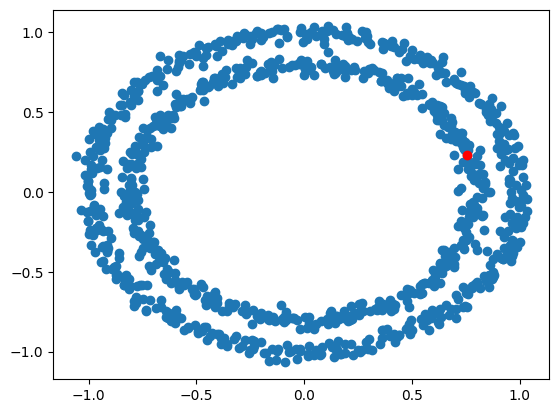

In [48]:
plt.scatter(X[:,0],X[:,1])
plt.scatter(X[0,0],X[0,1], c="red")

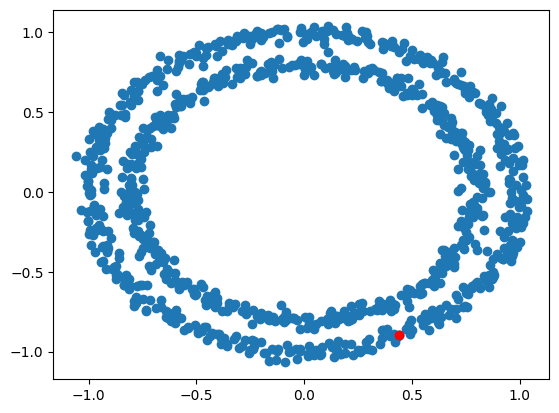

In [49]:
plt.scatter(X[:,0],X[:,1])
plt.scatter(X[4,0],X[4,1], c="red")

In [50]:
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train,X_test, y_train,y_test = train_test_split(X,y, random_state=42, test_size=0.2)

In [249]:
import torch.nn.functional as F
class CicleClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(2,10)
        self.linear2 = nn.Linear(10,10)
        self.linear3 = nn.Linear(10,1)
    
    def forward(self,x:torch.tensor) -> torch.tensor:
        x = self.linear1(x)
        x = F.sigmoid(x)
        x = self.linear2(x)
        x = F.relu(x)
        x = self.linear3(x)
        x = F.sigmoid(x)
        return x

torch.manual_seed(42)
model = CicleClassification()

loss_function = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

loss_function, optimizer, model

(BCELoss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     weight_decay: 0
 ),
 CicleClassification(
   (linear1): Linear(in_features=2, out_features=10, bias=True)
   (linear2): Linear(in_features=10, out_features=10, bias=True)
   (linear3): Linear(in_features=10, out_features=1, bias=True)
 ))

In [255]:
# def accuracy_score(y_true, y_pred):
#     corrcect = np.sum((y_true == y_pred).numpy())
#     return (corrcect/len(y_true))

def accuracy_score(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

epochs = 400


epoch_count = []
loss_values_train = []
loss_values_test = []
accuracy_train = []
accuracy_test = []

for epoch in range(epochs):
    model.train()

    pred_train = model(X_train).squeeze()
    pred_train_class = torch.round(pred_train)

    loss_train = loss_function(pred_train, y_train)

    optimizer.zero_grad()

    loss_train.backward()
    optimizer.step()


    model.eval()
    with torch.inference_mode():
        pred_test = model(X_test).squeeze()
        pred_test_class = torch.round(pred_test)

        loss_test = loss_function(pred_test, y_test)

    if epoch % 10 == 1:
        epoch_count.append(epoch)
        
        loss_values_train.append(loss_train.item())
        loss_values_test.append(loss_test.item())

        acc_train = accuracy_score(y_train, pred_train_class)
        acc_test = accuracy_score(y_test, pred_test_class)
        accuracy_train.append(acc_train)
        accuracy_test.append(acc_test)

        print(f"Epoch: {epoch} | Loss: {loss_train:.5f}, Accuracy: {acc_train:.2f}% | Test loss: {loss_test:.5f}, Test acc: {acc_test:.2f}%")


Epoch: 1 | Loss: 0.00225, Accuracy: 100.00% | Test loss: 0.00734, Test acc: 100.00%
Epoch: 11 | Loss: 0.00219, Accuracy: 100.00% | Test loss: 0.00721, Test acc: 100.00%
Epoch: 21 | Loss: 0.00214, Accuracy: 100.00% | Test loss: 0.00709, Test acc: 100.00%
Epoch: 31 | Loss: 0.00209, Accuracy: 100.00% | Test loss: 0.00698, Test acc: 100.00%
Epoch: 41 | Loss: 0.00204, Accuracy: 100.00% | Test loss: 0.00687, Test acc: 100.00%
Epoch: 51 | Loss: 0.00200, Accuracy: 100.00% | Test loss: 0.00677, Test acc: 100.00%
Epoch: 61 | Loss: 0.00195, Accuracy: 100.00% | Test loss: 0.00666, Test acc: 100.00%
Epoch: 71 | Loss: 0.00191, Accuracy: 100.00% | Test loss: 0.00657, Test acc: 100.00%
Epoch: 81 | Loss: 0.00187, Accuracy: 100.00% | Test loss: 0.00648, Test acc: 100.00%
Epoch: 91 | Loss: 0.00183, Accuracy: 100.00% | Test loss: 0.00638, Test acc: 100.00%
Epoch: 101 | Loss: 0.00179, Accuracy: 100.00% | Test loss: 0.00630, Test acc: 100.00%
Epoch: 111 | Loss: 0.00175, Accuracy: 100.00% | Test loss: 0.0062

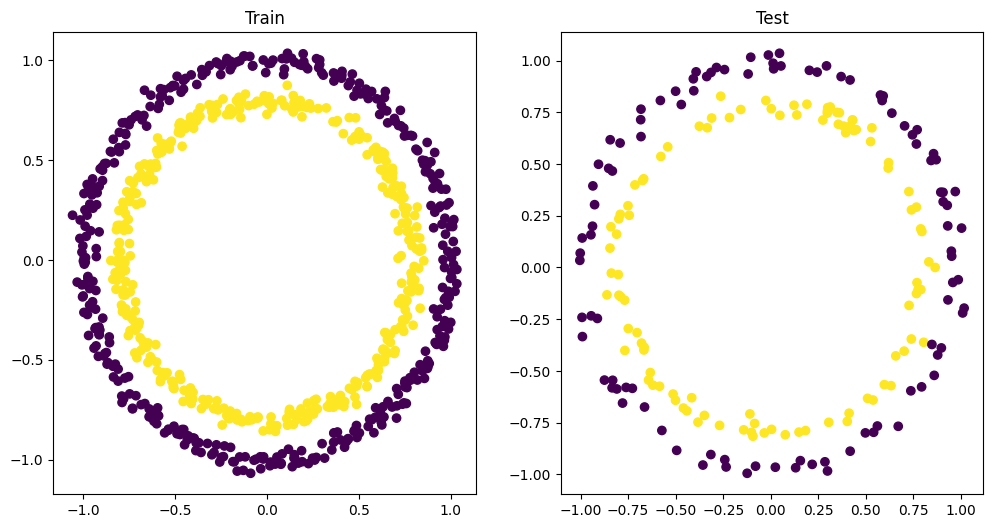

In [248]:
pred_train_class = [1 if i > 0.5 else 0 for i in pred_train]
pred_test_class = [1 if i > 0.5 else 0 for i in pred_test]

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plt.scatter(X_train[:,0], X_train[:,1], c=pred_train_class)
plt.subplot(1,2,2)
plt.title("Test")
plt.scatter(X_test[:,0], X_test[:,1], c=pred_test_class)
plt.show()

In [241]:
import requests
from pathlib import Path


if Path("fuctions.py").exists():
    print("it exists")
else:
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("functions.py", "wb") as f:
        f.write(request.content)

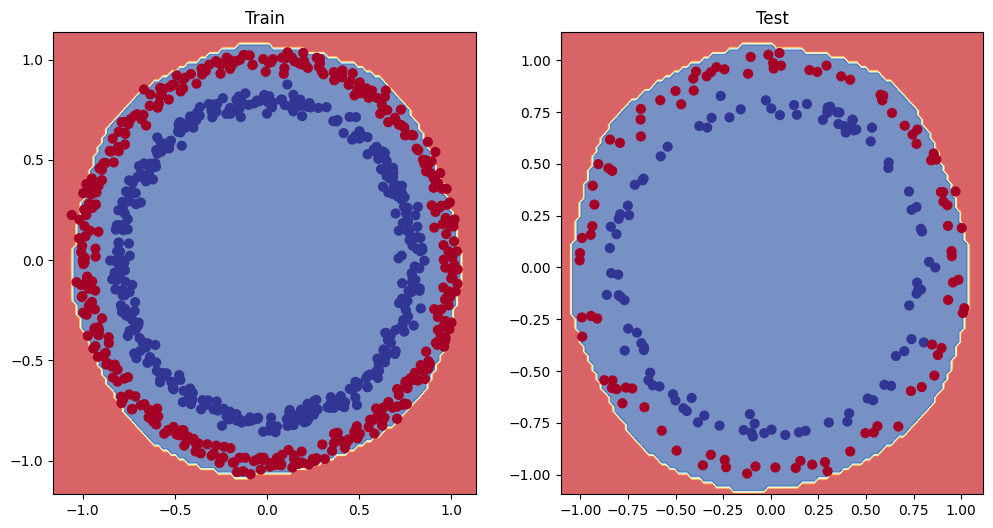

In [256]:
from functions import plot_decision_boundary, plot_predictions

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)


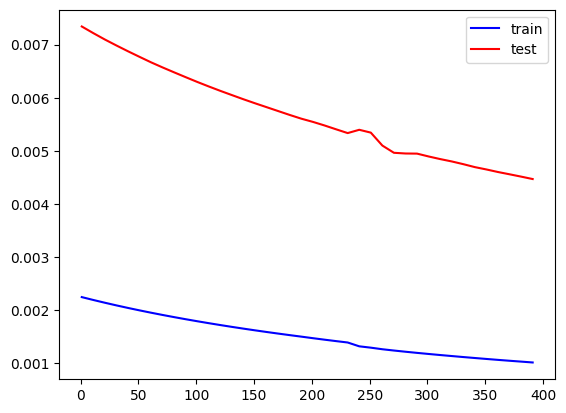

In [257]:
plt.plot(epoch_count, loss_values_train, c="blue", label="train")
plt.plot(epoch_count, loss_values_test, c="red", label="test")
plt.legend()
plt.show()

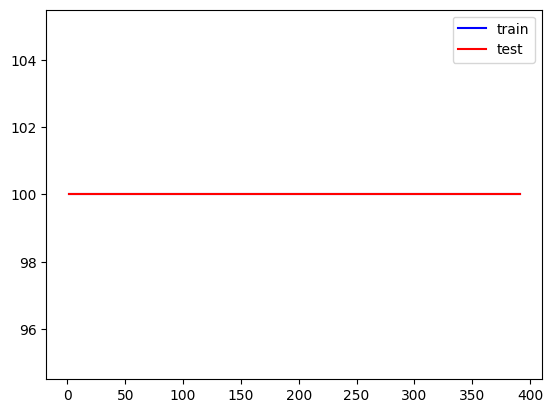

In [254]:
plt.plot(epoch_count, accuracy_train, c="blue", label="train")
plt.plot(epoch_count, accuracy_test, c="red", label="test")
plt.legend()
plt.show()

In [276]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1000, 
                  n_features=2, 
                  centers=4, 
                  random_state=42,
                  cluster_std=1.5)

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.long)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

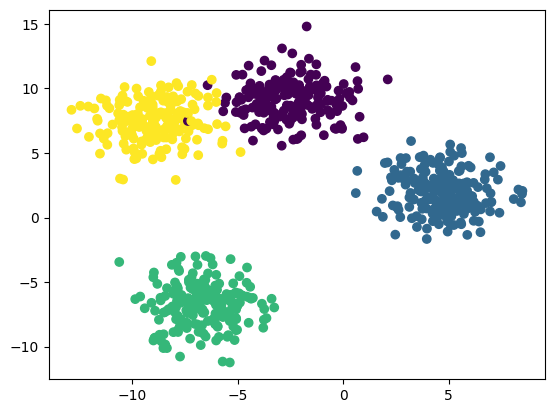

In [277]:
plt.scatter(X_train[:,0],X_train[:,1], c=y_train)

In [300]:
class CicleClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(2,10)
        self.linear2 = nn.Linear(10,10)
        self.linear3 = nn.Linear(10,4)
    
    def forward(self,x:torch.tensor) -> torch.tensor:
        x = self.linear1(x)
        x = F.sigmoid(x)
        x = self.linear2(x)
        x = F.sigmoid(x)
        x = self.linear3(x)
        x = F.softmax(x)
        return x

torch.manual_seed(42)
model = CicleClassification()

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

loss_function, optimizer, model

(CrossEntropyLoss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     weight_decay: 0
 ),
 CicleClassification(
   (linear1): Linear(in_features=2, out_features=10, bias=True)
   (linear2): Linear(in_features=10, out_features=10, bias=True)
   (linear3): Linear(in_features=10, out_features=4, bias=True)
 ))

In [301]:
epochs = 100


epoch_count = []
loss_values_train = []
loss_values_test = []
accuracy_train = []
accuracy_test = []

for epoch in range(epochs):
    model.train()

    pred_train = model(X_train).squeeze()
    pred_train_class = pred_train.argmax(axis=1)

    loss_train = loss_function(pred_train, y_train)

    optimizer.zero_grad()

    loss_train.backward()
    optimizer.step()


    model.eval()
    with torch.inference_mode():
        pred_test = model(X_test).squeeze()
        pred_test_class = pred_test.argmax(axis=1)

        loss_test = loss_function(pred_test, y_test)

    if epoch % 10 == 1:
        epoch_count.append(epoch)
        
        loss_values_train.append(loss_train.item())
        loss_values_test.append(loss_test.item())

        acc_train = accuracy_score(y_train, pred_train_class)
        acc_test = accuracy_score(y_test, pred_test_class)
        accuracy_train.append(acc_train)
        accuracy_test.append(acc_test)

        print(f"Epoch: {epoch} | Loss: {loss_train:.5f}, Accuracy: {acc_train:.2f}% | Test loss: {loss_test:.5f}, Test acc: {acc_test:.2f}%")


Epoch: 1 | Loss: 1.38794, Accuracy: 26.00% | Test loss: 1.39054, Test acc: 44.50%
Epoch: 11 | Loss: 1.36188, Accuracy: 26.12% | Test loss: 1.36589, Test acc: 20.50%
Epoch: 21 | Loss: 1.31181, Accuracy: 74.50% | Test loss: 1.31393, Test acc: 75.50%
Epoch: 31 | Loss: 1.22515, Accuracy: 74.88% | Test loss: 1.22554, Test acc: 75.50%
Epoch: 41 | Loss: 1.11966, Accuracy: 90.88% | Test loss: 1.11885, Test acc: 96.00%
Epoch: 51 | Loss: 1.01686, Accuracy: 99.25% | Test loss: 1.01688, Test acc: 99.50%
Epoch: 61 | Loss: 0.93522, Accuracy: 99.25% | Test loss: 0.93318, Test acc: 99.50%
Epoch: 71 | Loss: 0.87592, Accuracy: 99.25% | Test loss: 0.87239, Test acc: 99.50%
Epoch: 81 | Loss: 0.83493, Accuracy: 99.38% | Test loss: 0.83060, Test acc: 99.50%
Epoch: 91 | Loss: 0.80705, Accuracy: 99.25% | Test loss: 0.80300, Test acc: 99.50%


/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_84480/533822849.py:14: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.softmax(x)


/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_84480/533822849.py:14: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.softmax(x)


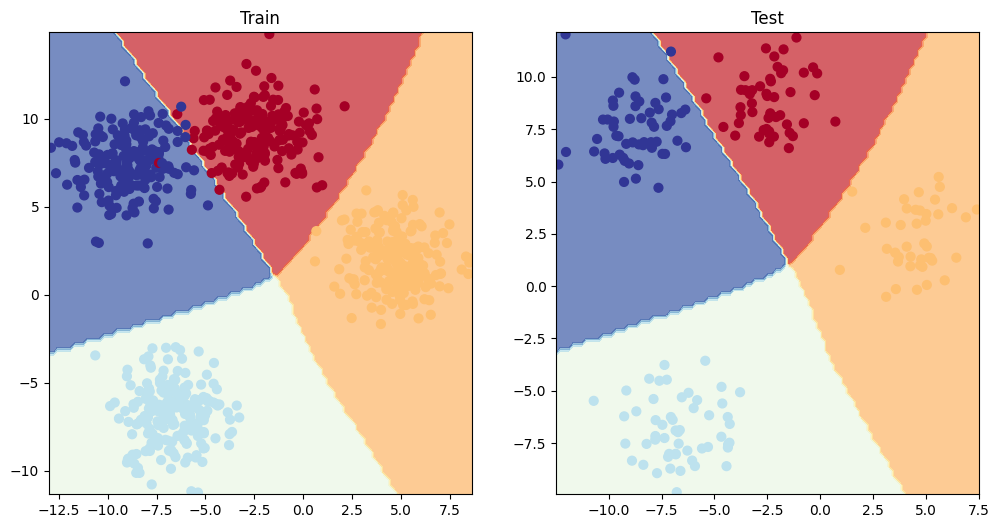

In [302]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

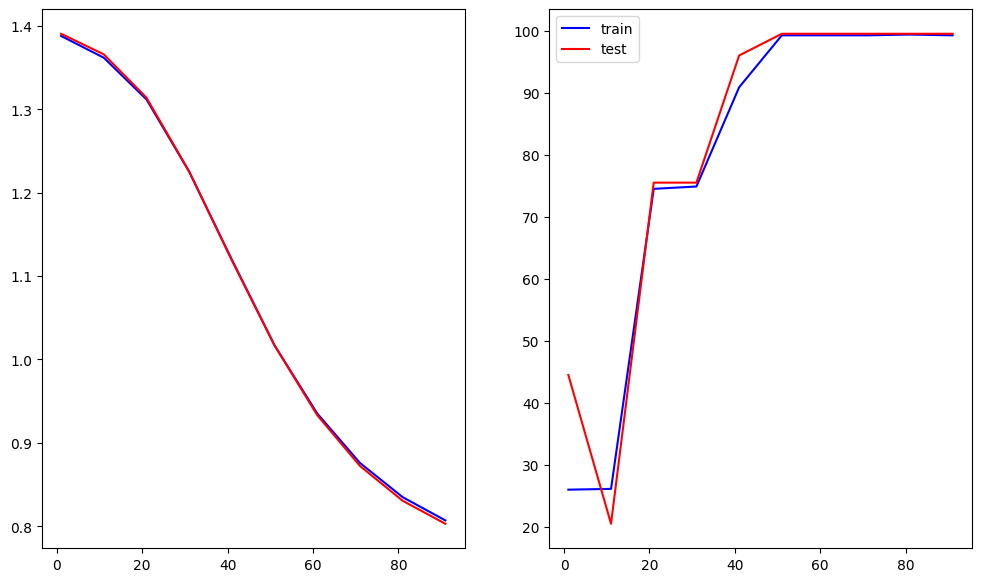

In [303]:
plt.figure(figsize=(12,7))

plt.subplot(1,2,1)
plt.plot(epoch_count, loss_values_train, c="blue", label="train")
plt.plot(epoch_count, loss_values_test, c="red", label="test")

plt.subplot(1,2,2)
plt.plot(epoch_count, accuracy_train, c="blue", label="train")
plt.plot(epoch_count, accuracy_test, c="red", label="test")
plt.legend()
plt.show()